# PCA — Метод Главных Компонент

Темы:
1. Проблема «слишком много признаков»
2. Геометрия проекций
3. Дисперсия и ковариационная матрица
4. Eigen decomposition → PCA
5. SVD → тот же результат, но лучше
6. Low-rank approximation
7. PCA на реальных данных
8. Ограничения


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_circles, make_swiss_roll
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
np.random.seed(42)


---
## 1. Проблема «слишком много признаков»

В реальных задачах признаков может быть сотни и тысячи:
- пиксели изображения (64×64 = 4096 признаков)
- слова в документе (TF-IDF: 100k признаков)
- гены в биоинформатике (20k+ признаков)

### Проклятие размерности

Чем больше измерений — тем **разреженнее** данные.
В высоких размерностях расстояния между точками становятся похожими:

$$d_{\min} \approx d_{\max} \quad \text{при } p \to \infty$$

Это ломает метрические алгоритмы (KNN, K-Means, SVM с RBF).


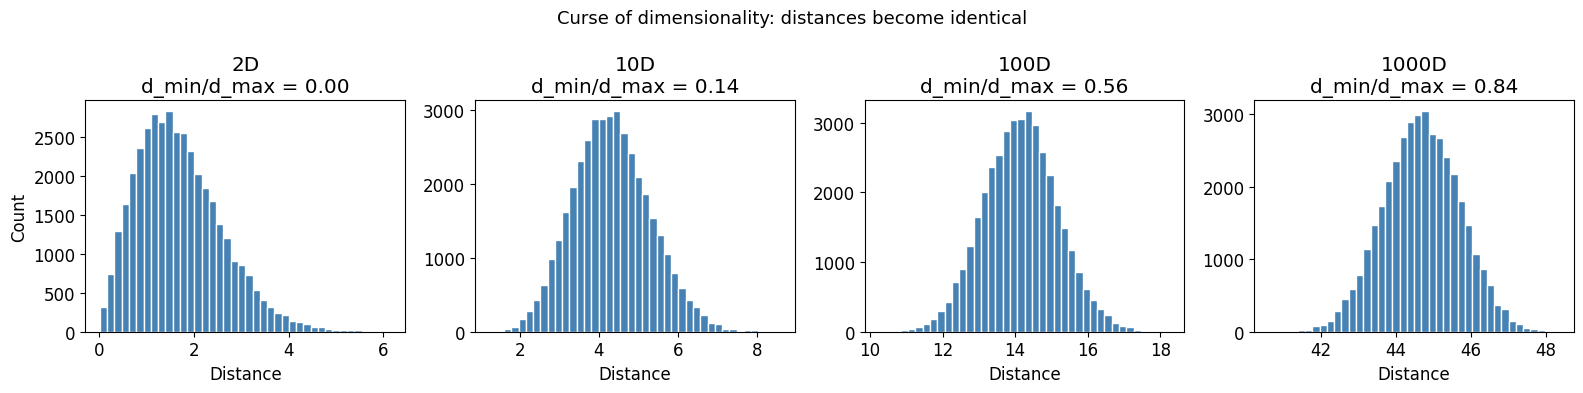

In [2]:
from scipy.spatial.distance import cdist

dims = [2, 10, 100, 1000]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, d in zip(axes, dims):
    X = np.random.randn(200, d)
    dists = cdist(X, X).ravel()
    dists = dists[dists > 0]
    ax.hist(dists, bins=40, color='steelblue', edgecolor='white')
    ratio = dists.min() / dists.max()
    ax.set_title(f'{d}D\nd_min/d_max = {ratio:.2f}')
    ax.set_xlabel('Distance')
    if d == 2:
        ax.set_ylabel('Count')

plt.suptitle('Curse of dimensionality: distances become identical', fontsize=13)
plt.tight_layout()
plt.show()


При $d=2$: расстояния варьируются сильно (можно различить «близко» и «далеко»).
При $d=1000$: все расстояния почти одинаковы — метрика теряет смысл.

**Решение:** уменьшить количество признаков, сохранив максимум информации.


---
## 2. Геометрия: проекции

Дано: облако точек $X \in \mathbb{R}^{n \times p}$.
Хотим: найти направление $\mathbf{u} \in \mathbb{R}^p$, $\|\mathbf{u}\| = 1$, куда спроецировать данные.

Проекция точки $\mathbf{x}_i$ на направление $\mathbf{u}$:

$$z_i = \mathbf{x}_i^\top \mathbf{u}$$

Хотим выбрать $\mathbf{u}$ так, чтобы проекции $z_i$ были **максимально разнообразны** — то есть имели максимальную **дисперсию**.

**Вопрос:** в каком направлении разброс данных максимален?

[Visualization](https://setosa.io/ev/principal-component-analysis/)


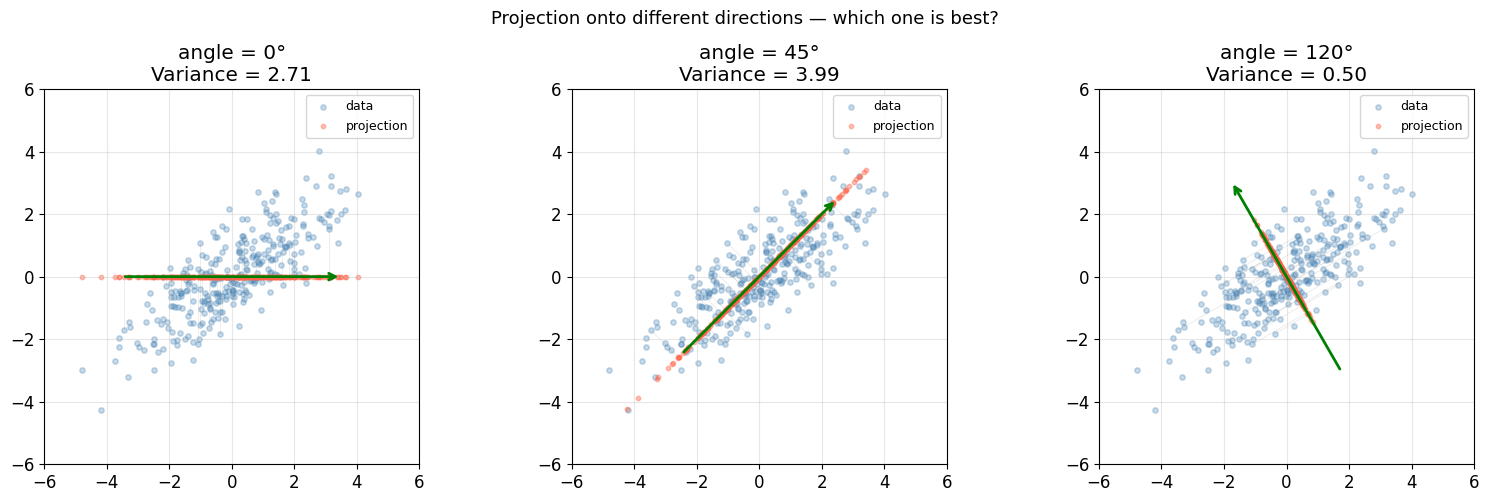

In [3]:
# Correlated 2D data
cov_true = [[3, 2], [2, 2]]
X = np.random.multivariate_normal([0, 0], cov_true, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

angles_deg = [0, 45, 120]
for ax, angle in zip(axes, angles_deg):
    theta = np.radians(angle)
    u = np.array([np.cos(theta), np.sin(theta)])

    # Project onto u
    proj_scalar = X @ u          # shape (n,)
    X_proj = np.outer(proj_scalar, u)  # back to 2D

    ax.scatter(X[:, 0], X[:, 1], alpha=0.3, s=15, label='data', color='steelblue')
    ax.scatter(X_proj[:, 0], X_proj[:, 1], alpha=0.4, s=10, color='tomato', label='projection')

    # Draw projection lines
    for xi, xpi in zip(X[:40], X_proj[:40]):
        ax.plot([xi[0], xpi[0]], [xi[1], xpi[1]], 'gray', alpha=0.2, linewidth=0.5)

    # Draw direction
    scale = 3.5
    ax.annotate('', xy=(u[0]*scale, u[1]*scale), xytext=(-u[0]*scale, -u[1]*scale),
                arrowprops=dict(arrowstyle='->', color='green', lw=2))

    var = proj_scalar.var()
    ax.set_title(f'angle = {angle}°\nVariance = {var:.2f}')
    ax.set_aspect('equal')
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle('Projection onto different directions — which one is best?', fontsize=13)
plt.tight_layout()
plt.show()


Best projection angle: 37.6°
Max variance: 4.053


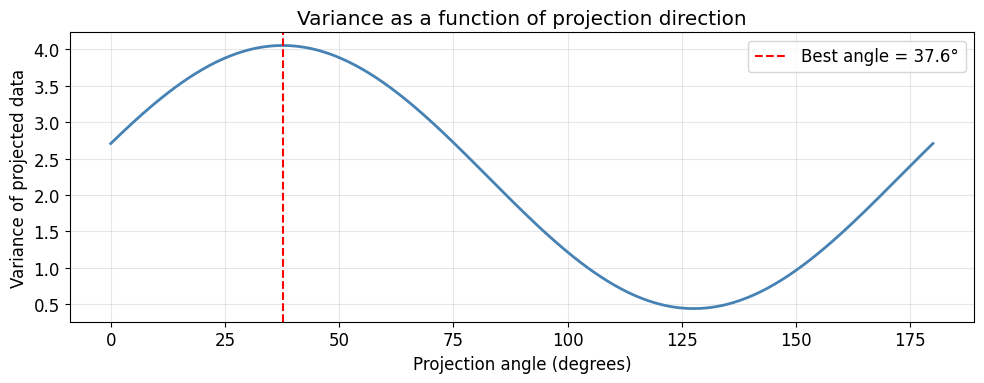

In [4]:
# Scan all angles and find the one with maximum variance
angles = np.linspace(0, 180, 360)
variances = []

for angle in angles:
    theta = np.radians(angle)
    u = np.array([np.cos(theta), np.sin(theta)])
    variances.append((X @ u).var())

best_angle = angles[np.argmax(variances)]
print(f'Best projection angle: {best_angle:.1f}°')
print(f'Max variance: {max(variances):.3f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(angles, variances, color='steelblue', linewidth=2)
ax.axvline(best_angle, color='red', linestyle='--', label=f'Best angle = {best_angle:.1f}°')
ax.set_xlabel('Projection angle (degrees)')
ax.set_ylabel('Variance of projected data')
ax.set_title('Variance as a function of projection direction')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 3. Дисперсия и ковариационная матрица

### Формализация задачи

Дисперсия проекций на направление $\mathbf{u}$:

$$\text{Var}(\mathbf{u}) = \frac{1}{n-1} \sum_{i=1}^n (\mathbf{x}_i^\top \mathbf{u})^2 = \mathbf{u}^\top \mathbf{C} \, \mathbf{u}$$

где $\mathbf{C}$ — **ковариационная матрица**:

$$\mathbf{C} = \frac{1}{n-1} X_c^\top X_c, \quad X_c = X - \bar{X}$$

Задача максимизации:

$$\max_{\|\mathbf{u}\|=1} \mathbf{u}^\top \mathbf{C} \, \mathbf{u}$$

По теореме Лагранжа, решение — **собственный вектор** $\mathbf{C}$ с наибольшим **собственным числом**.


In [5]:
# Covariance matrix — manual computation
X_c = X - X.mean(axis=0)    # center
n = X_c.shape[0]
C_manual = (X_c.T @ X_c) / (n - 1)

print('Covariance matrix (manual):')
print(C_manual)
print()
print('Covariance matrix (np.cov):')
print(np.cov(X.T))
print()
print('True covariance:')
print(np.array(cov_true))


Covariance matrix (manual):
[[2.71531273 1.75308096]
 [1.75308096 1.79216571]]

Covariance matrix (np.cov):
[[2.71531273 1.75308096]
 [1.75308096 1.79216571]]

True covariance:
[[3 2]
 [2 2]]


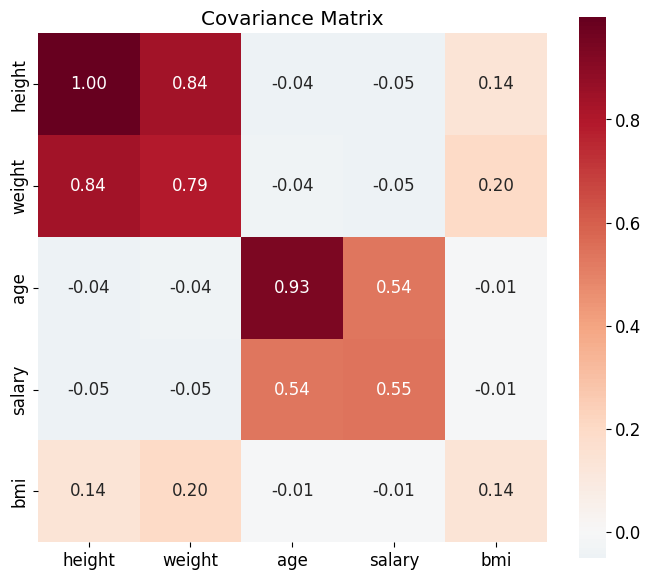

Strong positive correlation: height — weight
Negative correlation: bmi — height


In [6]:
# Covariance heatmap on a more interesting dataset
np.random.seed(0)
n_s = 500
# height, weight, age, salary, bmi — with realistic correlations
height = np.random.randn(n_s)
weight = 0.85 * height + 0.3 * np.random.randn(n_s)
age    = np.random.randn(n_s)
salary = 0.6 * age + 0.5 * np.random.randn(n_s)
bmi    = weight - 0.7 * height + 0.2 * np.random.randn(n_s)

X_demo = np.stack([height, weight, age, salary, bmi], axis=1)
features = ['height', 'weight', 'age', 'salary', 'bmi']

C_demo = np.cov(X_demo.T)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(C_demo, annot=True, fmt='.2f',
            xticklabels=features, yticklabels=features,
            cmap='RdBu_r', center=0, ax=ax, square=True)
ax.set_title('Covariance Matrix')
plt.tight_layout()
plt.show()

print('Strong positive correlation: height — weight')
print('Negative correlation: bmi — height')


---
## 4. Eigen Decomposition

Ковариационная матрица **симметрична и положительно полуопределена**.
По спектральной теореме она разлагается как:

$$\mathbf{C} = \mathbf{V} \Lambda \mathbf{V}^\top$$

где:
- $\Lambda = \text{diag}(\lambda_1, \lambda_2, \ldots, \lambda_p)$ — **собственные числа** (дисперсия вдоль каждой компоненты)
- $\mathbf{V}$ — матрица **собственных векторов** (столбцы — ортонормированный базис)

Сортируем по убыванию $\lambda_i$. Первый собственный вектор — главная компонента $PC_1$.

> `np.linalg.eigh` — специализирован для симметричных матриц, быстрее и численно стабильнее `np.linalg.eig`.


In [7]:
eigenvalues, eigenvectors = np.linalg.eigh(C_manual)

# eigh returns ascending order — reverse
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]  # columns are eigenvectors

print('Eigenvalues (variance along each PC):')
print(eigenvalues)
print()
print('Eigenvectors (columns = principal components):')
print(eigenvectors)
print()
print('Explained variance ratio:')
print(eigenvalues / eigenvalues.sum())


Eigenvalues (variance along each PC):
[4.06656656 0.44091188]

Eigenvectors (columns = principal components):
[[-0.79202754  0.61048535]
 [-0.61048535 -0.79202754]]

Explained variance ratio:
[0.90218214 0.09781786]


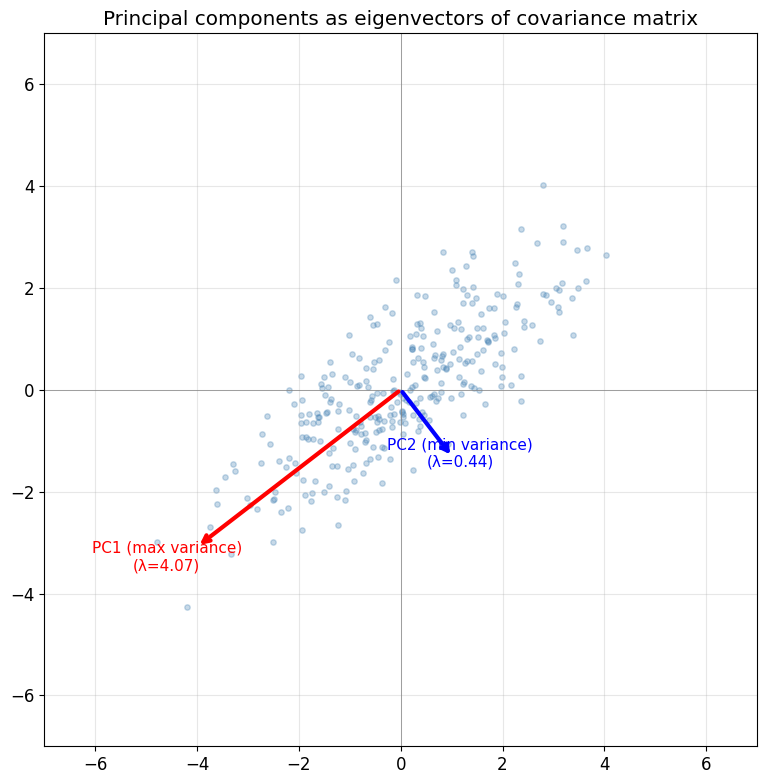

In [8]:
# Visualize eigenvectors as principal directions of the data
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X[:, 0], X[:, 1], alpha=0.3, s=15, color='steelblue')

colors = ['red', 'blue']
labels = ['PC1 (max variance)', 'PC2 (min variance)']

for i in range(2):
    vec = eigenvectors[:, i]
    val = eigenvalues[i]
    scale = np.sqrt(val) * 2.5
    ax.annotate('', xy=(vec[0]*scale, vec[1]*scale), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=3))
    ax.text(vec[0]*scale*1.15, vec[1]*scale*1.15,
            f'{labels[i]}\n(λ={val:.2f})',
            color=colors[i], ha='center', fontsize=11)

ax.set_aspect('equal')
ax.set_xlim(-7, 7); ax.set_ylim(-7, 7)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_title('Principal components as eigenvectors of covariance matrix')
plt.tight_layout()
plt.show()


---
## 5. PCA — алгоритм шаг за шагом

**Алгоритм:**
1. Центрировать данные: $X_c = X - \bar{X}$
2. Вычислить ковариационную матрицу: $\mathbf{C} = \frac{1}{n-1} X_c^\top X_c$
3. Найти собственные числа и векторы: $\mathbf{C} = \mathbf{V} \Lambda \mathbf{V}^\top$
4. Отсортировать по убыванию $\lambda_i$
5. Взять первые $k$ собственных векторов: $\mathbf{W} \in \mathbb{R}^{p \times k}$
6. Спроецировать данные: $Z = X_c \mathbf{W}$


In [9]:
class PCAFromScratch:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components_ = None          # shape (k, p)
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        X_c = X - self.mean_
        n = X_c.shape[0]

        C = (X_c.T @ X_c) / (n - 1)
        eigenvalues, eigenvectors = np.linalg.eigh(C)

        # Sort descending
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues   = eigenvalues[idx]
        eigenvectors  = eigenvectors[:, idx]

        self.components_             = eigenvectors[:, :self.n_components].T
        self.explained_variance_     = eigenvalues[:self.n_components]
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / eigenvalues.sum()
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_.T

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, Z):
        return Z @ self.components_ + self.mean_


Explained variance:       [4.067 0.441]
Explained variance ratio: [0.902 0.098]
Total explained:          1.0

Correlation in original space:  0.795
Correlation in PCA space:       -0.000


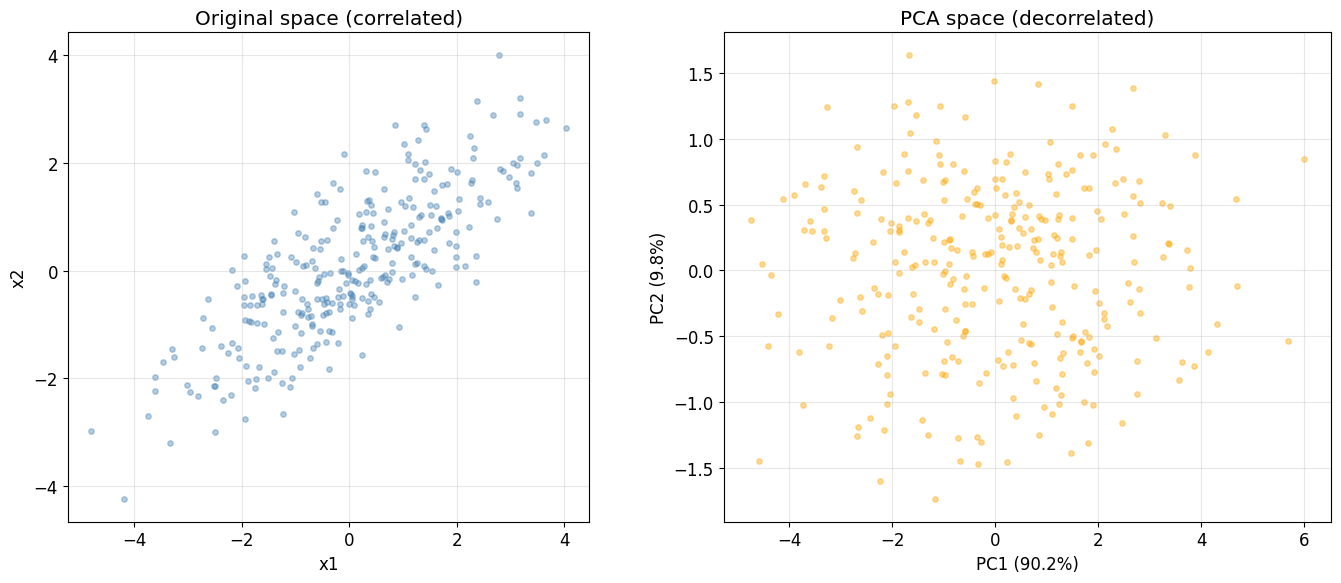

In [10]:
pca_scratch = PCAFromScratch(n_components=2)
X_pca = pca_scratch.fit_transform(X)

print('Explained variance:      ', np.round(pca_scratch.explained_variance_, 3))
print('Explained variance ratio:', np.round(pca_scratch.explained_variance_ratio_, 3))
print('Total explained:         ', pca_scratch.explained_variance_ratio_.sum().round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X[:, 0], X[:, 1], alpha=0.4, s=15, color='steelblue')
axes[0].set_title('Original space (correlated)')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, s=15, color='orange')
axes[1].set_title('PCA space (decorrelated)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel(f'PC1 ({pca_scratch.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_scratch.explained_variance_ratio_[1]:.1%})')

# Check: PCA axes should be uncorrelated
print(f'\nCorrelation in original space:  {np.corrcoef(X.T)[0, 1]:.3f}')
print(f'Correlation in PCA space:       {np.corrcoef(X_pca.T)[0, 1]:.3f}')

plt.tight_layout()
plt.show()


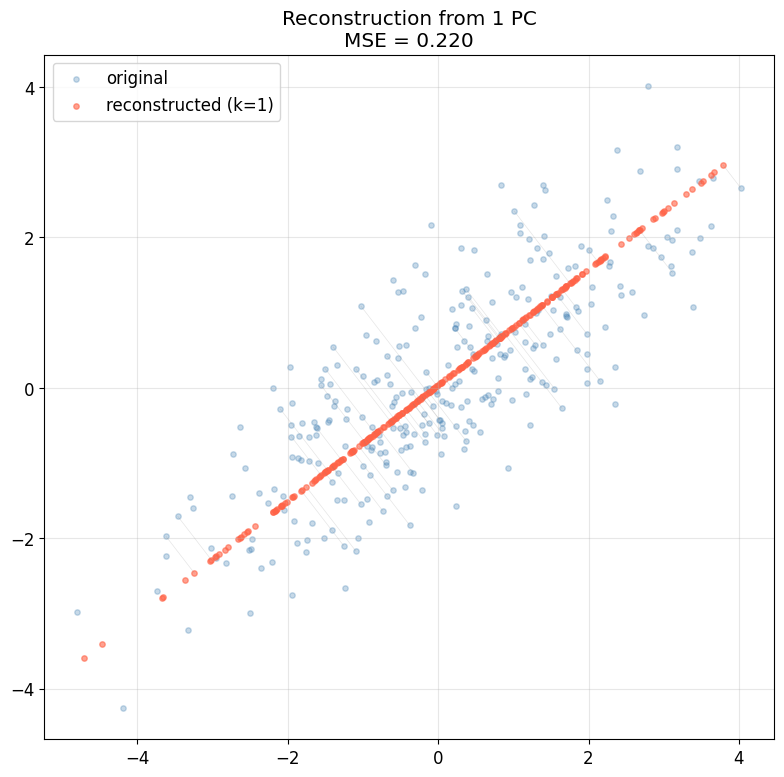

In [11]:
# Reconstruction from 1 component
pca_1d = PCAFromScratch(n_components=1)
pca_1d.fit(X)
X_1d = pca_1d.transform(X)
X_reconstructed = pca_1d.inverse_transform(X_1d)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X[:, 0], X[:, 1], alpha=0.3, s=15, color='steelblue', label='original')
ax.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1],
           alpha=0.6, s=15, color='tomato', label='reconstructed (k=1)')

for xi, xr in zip(X[:60], X_reconstructed[:60]):
    ax.plot([xi[0], xr[0]], [xi[1], xr[1]], 'gray', alpha=0.2, linewidth=0.5)

reconstruction_error = np.mean((X - X_reconstructed)**2)
ax.set_title(f'Reconstruction from 1 PC\nMSE = {reconstruction_error:.3f}')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


---
## 6. PCA через sklearn

`sklearn.decomposition.PCA` использует SVD внутри (раздел 7).
Результат тот же, знаки компонент могут отличаться — это допустимо.


In [12]:
from sklearn.decomposition import PCA as SklearnPCA

pca_sk = SklearnPCA(n_components=2)
X_pca_sk = pca_sk.fit_transform(X)

print('sklearn explained_variance_ratio_:', np.round(pca_sk.explained_variance_ratio_, 4))
print('manual  explained_variance_ratio_:', np.round(pca_scratch.explained_variance_ratio_, 4))

# Signs may be flipped — check absolute values of components
print()
print('sklearn components_:\n', np.round(pca_sk.components_, 4))
print('manual  components_:\n', np.round(pca_scratch.components_, 4))
print()
print('Max difference (abs):', np.abs(np.abs(pca_sk.components_) - np.abs(pca_scratch.components_)).max())


sklearn explained_variance_ratio_: [0.9022 0.0978]
manual  explained_variance_ratio_: [0.9022 0.0978]

sklearn components_:
 [[ 0.792   0.6105]
 [-0.6105  0.792 ]]
manual  components_:
 [[-0.792  -0.6105]
 [ 0.6105 -0.792 ]]

Max difference (abs): 1.1102230246251565e-16


---
## 7. SVD — тот же результат, лучше численно

**Сингулярное разложение (SVD):**

$$X_c = U \Sigma V^\top$$

- $U \in \mathbb{R}^{n \times n}$ — левые сингулярные векторы (наблюдения)
- $\Sigma \in \mathbb{R}^{n \times p}$ — диагональная матрица сингулярных чисел $\sigma_i \geq 0$
- $V \in \mathbb{R}^{p \times p}$ — правые сингулярные векторы (признаки)

**Связь с PCA:**

$$\mathbf{C} = \frac{X_c^\top X_c}{n-1} = \frac{V \Sigma^\top U^\top U \Sigma V^\top}{n-1} = V \frac{\Sigma^2}{n-1} V^\top$$

Значит:
- Столбцы $V$ = собственные векторы $\mathbf{C}$ = **главные компоненты**
- $\lambda_i = \sigma_i^2 / (n-1)$ = **собственные числа**
- Проекция: $Z = X_c V_k = U_k \Sigma_k$

**Почему SVD лучше eigh(C)?**
- Не вычисляем $X_c^\top X_c$ — избегаем потери точности при возведении в степень
- Численно стабильнее для вытянутых матриц ($n \gg p$ или $p \gg n$)


In [13]:
X_c = X - X.mean(axis=0)
n = X_c.shape[0]

U, S, Vt = np.linalg.svd(X_c, full_matrices=False)

# Eigenvalues from singular values
eigenvalues_svd = S**2 / (n - 1)
explained_ratio_svd = eigenvalues_svd / eigenvalues_svd.sum()

print('Eigenvalues from SVD:   ', np.round(eigenvalues_svd, 4))
print('Eigenvalues from eigh:  ', np.round(pca_scratch.explained_variance_, 4))
print()
print('Explained ratio (SVD):  ', np.round(explained_ratio_svd, 4))
print('Explained ratio (eigh): ', np.round(pca_scratch.explained_variance_ratio_, 4))


Eigenvalues from SVD:    [4.0666 0.4409]
Eigenvalues from eigh:   [4.0666 0.4409]

Explained ratio (SVD):   [0.9022 0.0978]
Explained ratio (eigh):  [0.9022 0.0978]


Max difference between SVD and eigh projections: 3.66e-15


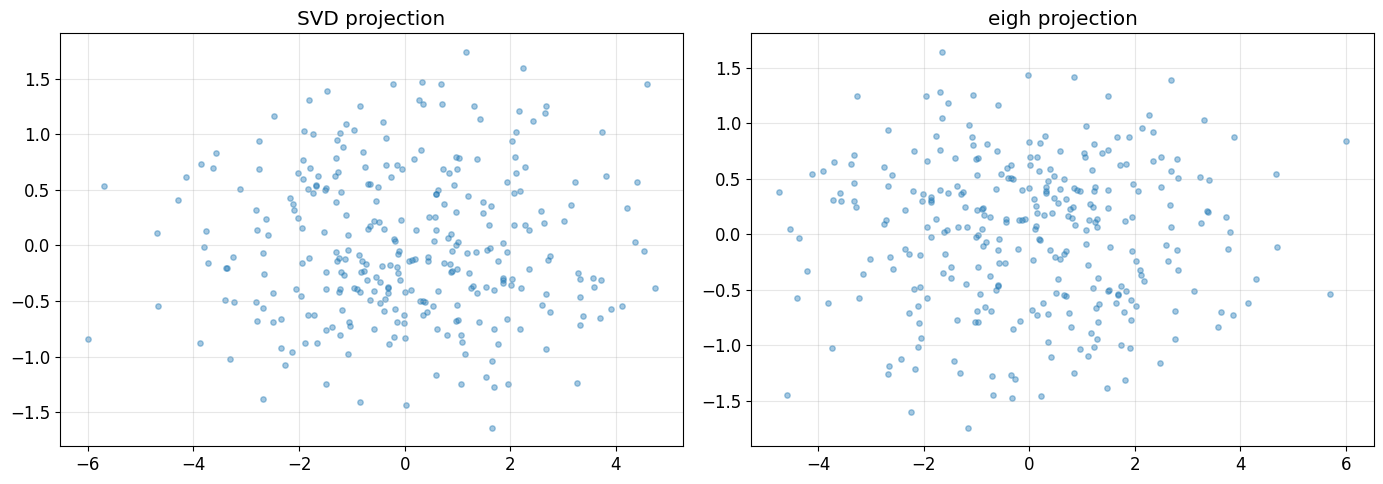

In [14]:
# Projection via SVD
Z_svd  = U[:, :2] * S[:2]          # = X_c @ Vt[:2].T
Z_eigh = pca_scratch.transform(X)

# Results should be identical up to sign flip
diff = np.abs(np.abs(Z_svd) - np.abs(Z_eigh)).max()
print(f'Max difference between SVD and eigh projections: {diff:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, Z, title in zip(axes, [Z_svd, Z_eigh], ['SVD projection', 'eigh projection']):
    ax.scatter(Z[:, 0], Z[:, 1], alpha=0.4, s=15)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 8. Low-rank Approximation

SVD даёт **оптимальное приближение** матрицы заданного ранга $k$ (теорема Эккарта-Янга):

$$A_k = \sum_{i=1}^k \sigma_i \mathbf{u}_i \mathbf{v}_i^\top = U_k \Sigma_k V_k^\top$$

Это приближение минимизирует ошибку по норме Фробениуса:

$$\|A - A_k\|_F^2 = \sum_{i=k+1}^{r} \sigma_i^2$$

**Применение:** сжатие изображений, рекомендательные системы, шумоподавление.


In [15]:
import imageio.v2 as imageio
import os

# Use existing course image for compression demo
img_path = '../9_rca_/Rosa_Peer_Gynt_1.jpg'

if os.path.exists(img_path):
    img = imageio.imread(img_path)
    # Convert to grayscale if RGB
    if img.ndim == 3:
        img_gray = img.mean(axis=2)
    else:
        img_gray = img.astype(float)
else:
    # Fallback: generate a synthetic low-rank image
    rng = np.random.default_rng(42)
    img_gray = (np.outer(np.sin(np.linspace(0, 3*np.pi, 200)),
                         np.cos(np.linspace(0, 2*np.pi, 300))) * 100
                + rng.normal(0, 20, (200, 300)))

A = img_gray.astype(float)
print(f'Image shape: {A.shape}')
print(f'Full rank:   {min(A.shape)}')

U, S, Vt = np.linalg.svd(A, full_matrices=False)
print(f'Singular values (first 10): {np.round(S[:10], 1)}')


Image shape: (200, 300)
Full rank:   200
Singular values (first 10): [12238.    620.1   613.8   608.4   594.9   588.6   579.9   570.7   570.5
   565.4]


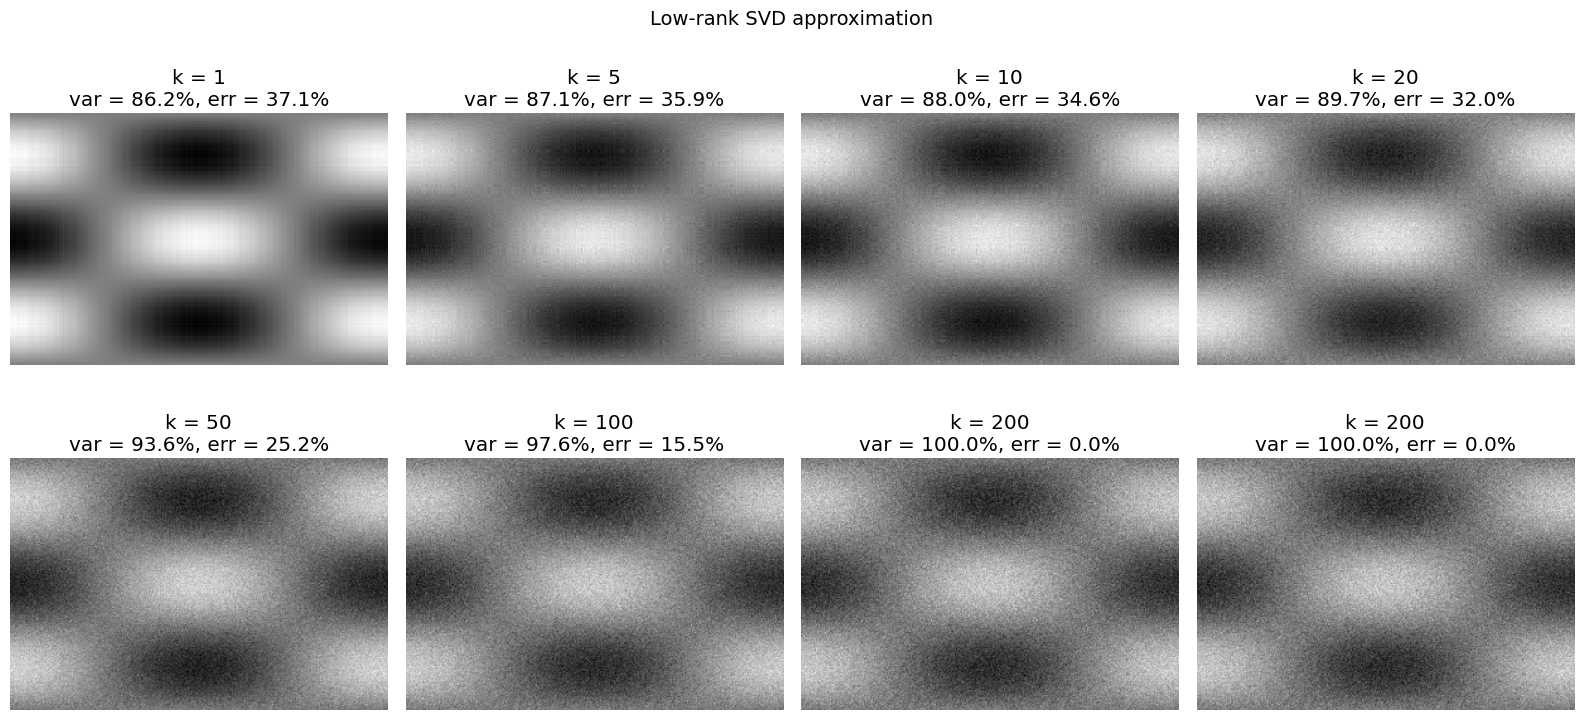

In [16]:
ks = [1, 5, 10, 20, 50, 100, 200, min(A.shape)]
n_show = min(8, len(ks))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, k in zip(axes.flat, ks[:n_show]):
    A_k = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

    variance = (S[:k]**2).sum() / (S**2).sum()
    error_rel = np.linalg.norm(A - A_k, 'fro') / np.linalg.norm(A, 'fro')

    ax.imshow(A_k, cmap='gray')
    ax.set_title(f'k = {k}\nvar = {variance:.1%}, err = {error_rel:.1%}')
    ax.axis('off')

plt.suptitle('Low-rank SVD approximation', fontsize=14)
plt.tight_layout()
plt.show()


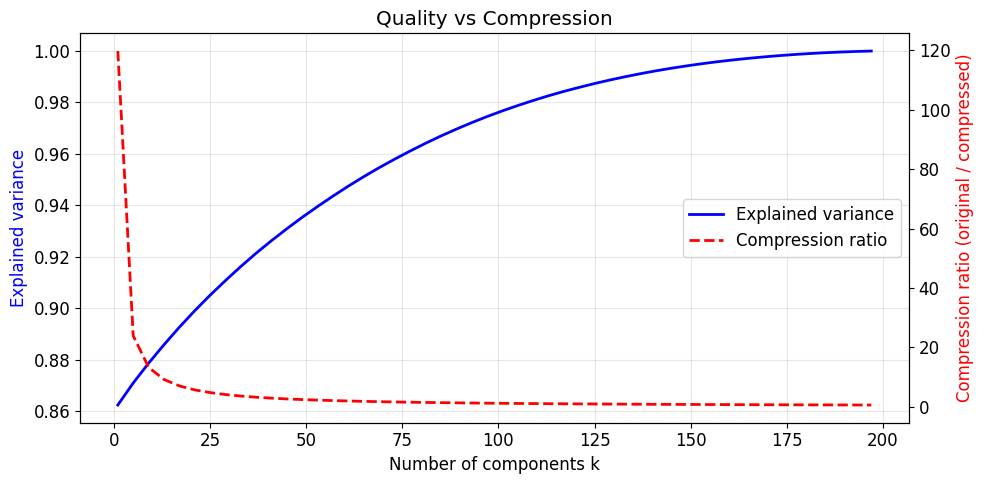

In [17]:
# Compression ratio vs quality
full_size = A.shape[0] * A.shape[1]
ks_range = range(1, min(A.shape) + 1, max(1, min(A.shape) // 50))

compression_ratios = []
variances = []
for k in ks_range:
    # Size: U[:,k] + S[k] + Vt[k,:]  = n*k + k + p*k = k*(n+p+1)
    compressed_size = k * (A.shape[0] + A.shape[1] + 1)
    compression_ratios.append(full_size / compressed_size)
    variances.append((S[:k]**2).sum() / (S**2).sum())

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(list(ks_range), variances, 'b-', linewidth=2, label='Explained variance')
ax2.plot(list(ks_range), compression_ratios, 'r--', linewidth=2, label='Compression ratio')

ax1.set_xlabel('Number of components k')
ax1.set_ylabel('Explained variance', color='blue')
ax2.set_ylabel('Compression ratio (original / compressed)', color='red')
ax1.set_title('Quality vs Compression')
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.show()


---
## 9. PCA на реальных данных: MNIST Digits

Датасет: 1797 изображений цифр 0–9, каждое 8×8 = 64 пикселя.
Применим PCA для снижения с 64 до 2 измерений.


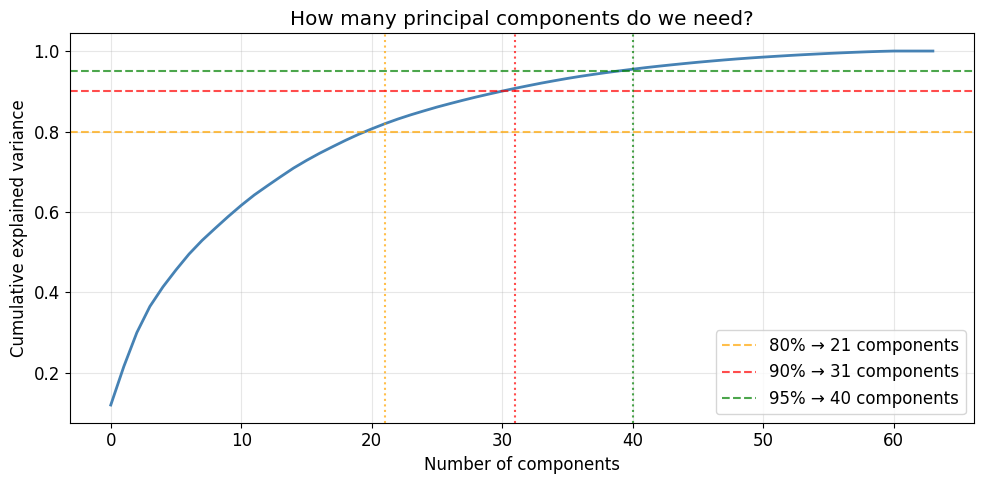

In [18]:
digits = load_digits()
X_digits = digits.data          # (1797, 64)
y_digits = digits.target

# Always scale before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_digits)

# Fit full PCA
pca_full = SklearnPCA()
pca_full.fit(X_scaled)

# How many components to keep?
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cumvar, linewidth=2, color='steelblue')
for threshold, color, label in [(0.80, 'orange', '80%'), (0.90, 'red', '90%'), (0.95, 'green', '95%')]:
    n_comp = np.argmax(cumvar >= threshold) + 1
    ax.axhline(threshold, color=color, linestyle='--', alpha=0.7, label=f'{label} → {n_comp} components')
    ax.axvline(n_comp, color=color, linestyle=':', alpha=0.7)

ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('How many principal components do we need?')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


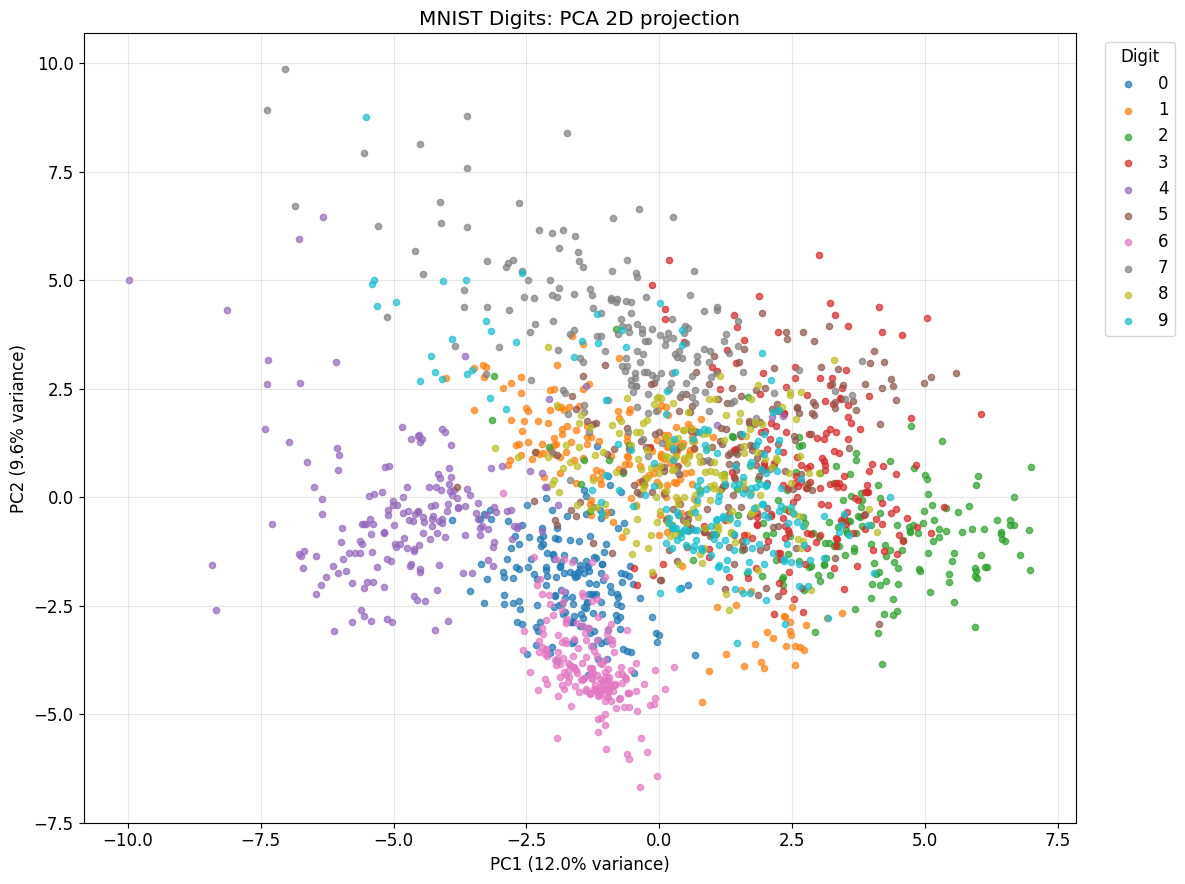

In [19]:
# Visualize in 2D
pca_2d = SklearnPCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 9))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for digit in range(10):
    mask = y_digits == digit
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[colors[digit]], label=str(digit), alpha=0.7, s=20)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('MNIST Digits: PCA 2D projection')
ax.legend(title='Digit', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


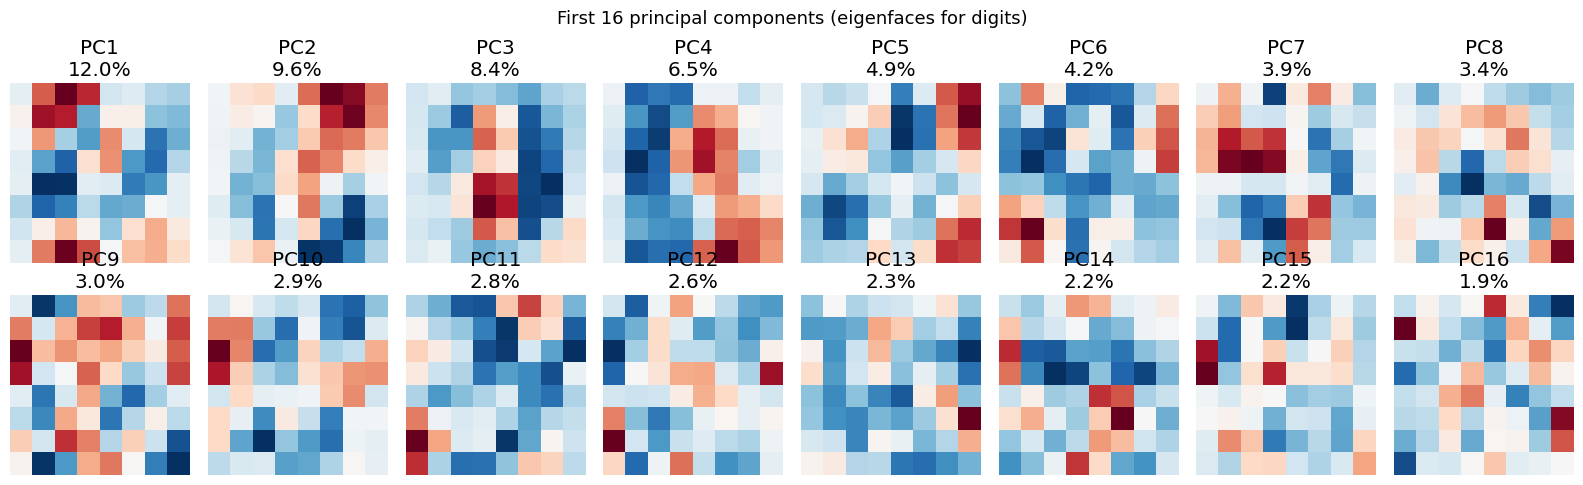

In [20]:
# Visualize first 16 principal components as images
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

for i, ax in enumerate(axes.flat):
    component = pca_full.components_[i].reshape(8, 8)
    ax.imshow(component, cmap='RdBu_r')
    ax.set_title(f'PC{i+1}\n{pca_full.explained_variance_ratio_[i]:.1%}')
    ax.axis('off')

plt.suptitle('First 16 principal components (eigenfaces for digits)', fontsize=13)
plt.tight_layout()
plt.show()


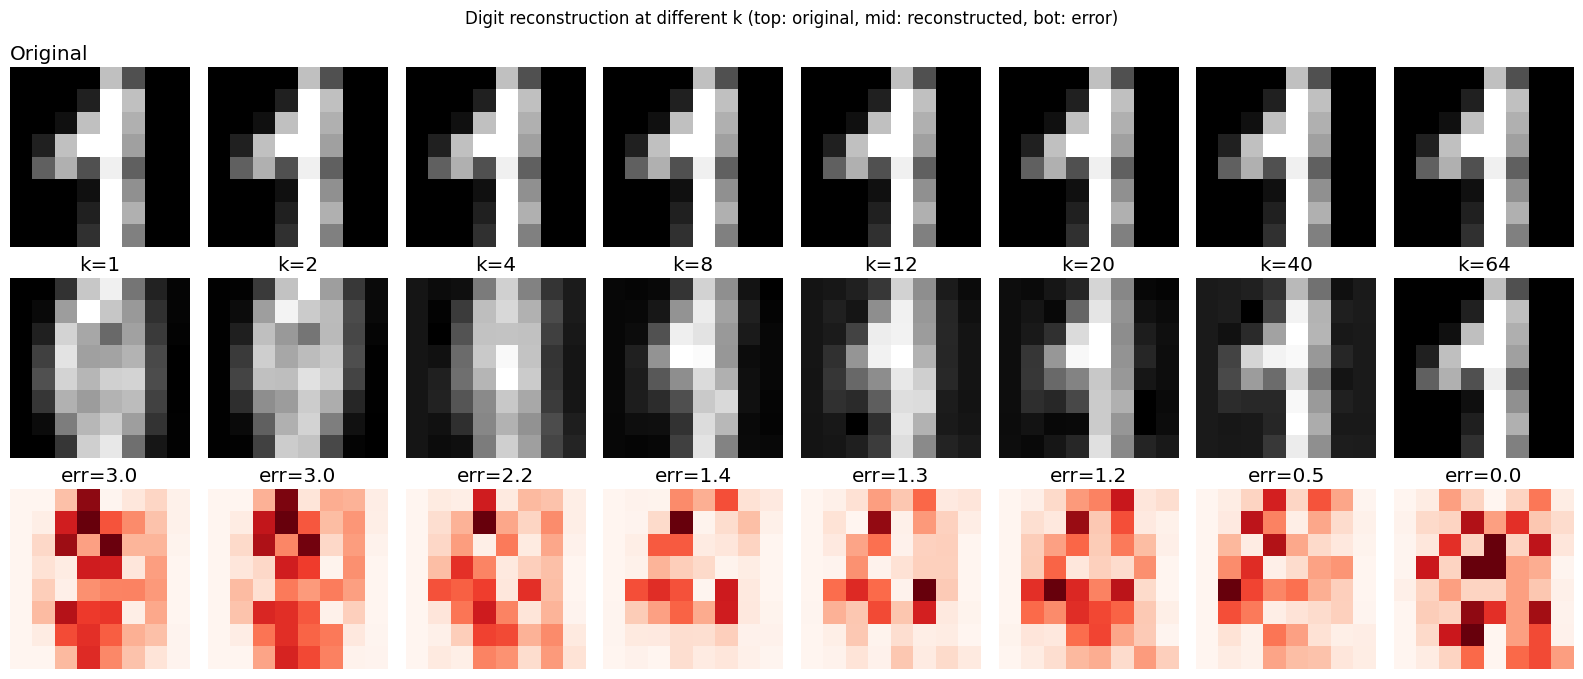

In [21]:
# Reconstruction quality at different k
fig, axes = plt.subplots(3, 8, figsize=(16, 7))
sample_idx = 42

original = X_digits[sample_idx]
ks_rec = [1, 2, 4, 8, 12, 20, 40, 64]

# Row 0: original
for ax in axes[0]:
    ax.imshow(original.reshape(8, 8), cmap='gray')
    ax.axis('off')
axes[0, 0].set_title('Original', loc='left')

# Row 1: reconstruction
for ax, k in zip(axes[1], ks_rec):
    pca_k = SklearnPCA(n_components=k)
    pca_k.fit(X_scaled)
    z = pca_k.transform(X_scaled[sample_idx:sample_idx+1])
    rec = scaler.inverse_transform(pca_k.inverse_transform(z))
    ax.imshow(rec.reshape(8, 8), cmap='gray')
    ax.set_title(f'k={k}')
    ax.axis('off')

# Row 2: residual
for ax, k in zip(axes[2], ks_rec):
    pca_k = SklearnPCA(n_components=k)
    pca_k.fit(X_scaled)
    z = pca_k.transform(X_scaled[sample_idx:sample_idx+1])
    rec = scaler.inverse_transform(pca_k.inverse_transform(z))
    residual = np.abs(original - rec.ravel())
    ax.imshow(residual.reshape(8, 8), cmap='Reds')
    ax.set_title(f'err={residual.mean():.1f}')
    ax.axis('off')

plt.suptitle('Digit reconstruction at different k (top: original, mid: reconstructed, bot: error)', fontsize=12)
plt.tight_layout()
plt.show()


---
## 10. Ограничения PCA

| Ограничение | Пояснение |
|---|---|
| **Только линейные зависимости** | PCA ищет линейные проекции, нелинейные структуры теряются |
| **Чувствительность к масштабу** | Обязательно стандартизировать данные |
| **Нет интерпретируемости** | Компоненты — линейные комбинации всех признаков |
| **Предполагает гауссово распределение** | Оптимально для гауссовых данных |

### Когда PCA не работает?


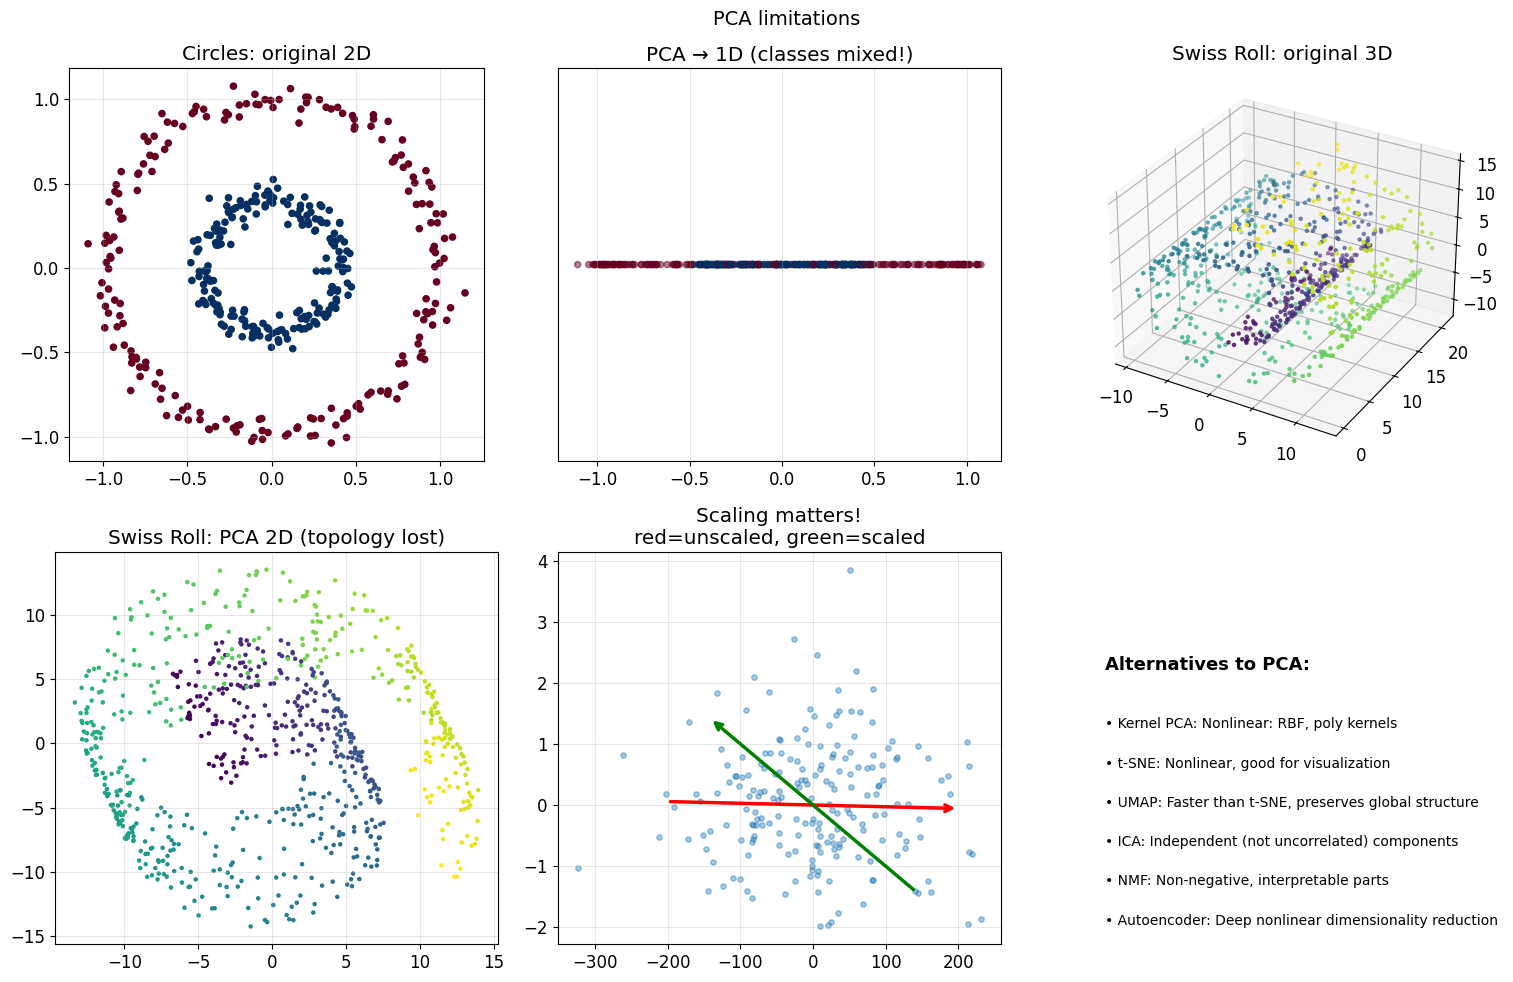

In [22]:
fig = plt.figure(figsize=(16, 10))

# --- Circles ---
X_circ, y_circ = make_circles(n_samples=400, noise=0.05, factor=0.4, random_state=42)

ax1 = fig.add_subplot(2, 3, 1)
ax1.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap='RdBu', s=20)
ax1.set_title('Circles: original 2D')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

pca_c = SklearnPCA(n_components=1)
X_1d = pca_c.fit_transform(X_circ)
ax2 = fig.add_subplot(2, 3, 2)
ax2.scatter(X_1d, np.zeros_like(X_1d), c=y_circ, cmap='RdBu', s=20, alpha=0.5)
ax2.set_title('PCA → 1D (classes mixed!)')
ax2.set_yticks([])
ax2.grid(True, alpha=0.3)

# --- Swiss roll ---
X_roll, t_roll = make_swiss_roll(n_samples=800, noise=0.1, random_state=42)
X_roll_pca = SklearnPCA(n_components=2).fit_transform(X_roll)

ax3 = fig.add_subplot(2, 3, 3, projection='3d')
ax3.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2], c=t_roll, cmap='viridis', s=5)
ax3.set_title('Swiss Roll: original 3D')

ax4 = fig.add_subplot(2, 3, 4)
ax4.scatter(X_roll_pca[:, 0], X_roll_pca[:, 1], c=t_roll, cmap='viridis', s=5)
ax4.set_title('Swiss Roll: PCA 2D (topology lost)')
ax4.grid(True, alpha=0.3)

# --- Scaling effect ---
np.random.seed(42)
X_unscaled = np.random.randn(200, 2)
X_unscaled[:, 0] *= 100   # feature 1 in centimetres, feature 2 in metres
X_unscaled[:, 1] *= 1

pca_unscaled = SklearnPCA(n_components=1)
pca_scaled   = SklearnPCA(n_components=1)
pca_unscaled.fit(X_unscaled)
pca_scaled.fit(StandardScaler().fit_transform(X_unscaled))

ax5 = fig.add_subplot(2, 3, 5)
ax5.scatter(X_unscaled[:, 0], X_unscaled[:, 1], alpha=0.4, s=15)
vec_u = pca_unscaled.components_[0]
vec_s = pca_scaled.components_[0] * np.array([100, 1])
ax5.annotate('', xy=vec_u*200, xytext=-vec_u*200,
             arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
ax5.annotate('', xy=vec_s*2, xytext=-vec_s*2,
             arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
ax5.set_title('Scaling matters!\nred=unscaled, green=scaled')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
ax6.text(0.1, 0.7, 'Alternatives to PCA:', fontsize=13, fontweight='bold')
alternatives = [
    ('Kernel PCA', 'Nonlinear: RBF, poly kernels'),
    ('t-SNE', 'Nonlinear, good for visualization'),
    ('UMAP', 'Faster than t-SNE, preserves global structure'),
    ('ICA', 'Independent (not uncorrelated) components'),
    ('NMF', 'Non-negative, interpretable parts'),
    ('Autoencoder', 'Deep nonlinear dimensionality reduction'),
]
for i, (name, desc) in enumerate(alternatives):
    ax6.text(0.1, 0.55 - i*0.1, f'• {name}: {desc}', fontsize=10)

plt.suptitle('PCA limitations', fontsize=14)
plt.tight_layout()
plt.show()


---
## Итог

| Шаг | Что делаем | Зачем |
|---|---|---|
| Центрирование | $X_c = X - \bar{X}$ | Убрать смещение |
| Ковариация | $C = X_c^\top X_c / (n-1)$ | Измерить разброс и связи |
| Eigendecomp / SVD | $C = V \Lambda V^\top$ | Найти главные направления |
| Проекция | $Z = X_c W_k$ | Снизить размерность |
| Реконструкция | $\hat{X} = Z W_k^\top + \bar{X}$ | Оценить потери |

**Ключевые параметры:**
- `n_components` — сколько компонент оставить
- Выбор: по `explained_variance_ratio_` (обычно 90–95%)
- **Всегда стандартизировать** данные перед PCA!
